# SHAP Analysis — Gradient Boosting (Best Model)

This notebook explains **why** the Gradient Boosting model makes its predictions using SHAP (SHapley Additive exPlanations).

The model predicts Parkinson's disease from voice measurements — but without explainability, it's a black box. SHAP opens that box: it assigns each feature a contribution score for every individual prediction.

### Notebook Sections:
1.  Retrain Gradient Boosting on preprocessed data
2.  **Summary Plot** — global feature importance
3.  **Beeswarm Plot** — how feature values push predictions
4.  **Waterfall Plot** — individual prediction explanation
5.  **Bar Plot** — ranking of mean absolute SHAP values
6.  **Cross-dataset SHAP** — feature importance generalizability

> **Prerequisite:** Run `PREPROCESSING.ipynb` first to generate the necessary preprocessed CSV files.

## 1. Install & Import Libraries

In [1]:
# Install SHAP if not already installed
!pip install shap --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap

from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import classification_report, roc_auc_score, f1_score

import warnings
warnings.filterwarnings('ignore')

# Initialize SHAP JS for notebook rendering
shap.initjs()

print("SHAP version:", shap.__version__)
print("All imports successful.")

SHAP version: 0.51.0
All imports successful.


## 2. Load Preprocessed Data

These files are expected to be generated by `PREPROCESSING.ipynb`.

In [3]:
import pandas as pd

# Load preprocessed Dataset 1 (train/test split already done in preprocessing)
df_d1_train = pd.read_csv('/content/ds1_train_preprocessed.csv')
X_train = df_d1_train.drop(columns=['status'])
y_train = df_d1_train['status'].squeeze()

df_d1_test = pd.read_csv('/content/ds1_test_preprocessed.csv')
X_test = df_d1_test.drop(columns=['status'])
y_test = df_d1_test['status'].squeeze()

# Load Dataset 3 for cross-dataset SHAP comparison
df_d3_test = pd.read_csv('/content/ds3_test_preprocessed.csv')
X_test_d3 = df_d3_test.drop(columns=['status'])
y_test_d3 = df_d3_test['status'].squeeze()

print(f"Training set:      {X_train.shape[0]} samples, {X_train.shape[1]} features")
print(f"Test set (D1):     {X_test.shape[0]} samples")
print(f"Test set (D3):     {X_test_d3.shape[0]} samples")
print(f"\nFeatures: {list(X_train.columns)}")

Training set:      156 samples, 22 features
Test set (D1):     39 samples
Test set (D3):     39 samples

Features: ['MDVP:Fo(Hz)', 'MDVP:Fhi(Hz)', 'MDVP:Flo(Hz)', 'MDVP:Jitter(%)', 'MDVP:Jitter(Abs)', 'MDVP:RAP', 'MDVP:PPQ', 'Jitter:DDP', 'MDVP:Shimmer', 'MDVP:Shimmer(dB)', 'Shimmer:APQ3', 'Shimmer:APQ5', 'MDVP:APQ', 'Shimmer:DDA', 'NHR', 'HNR', 'RPDE', 'DFA', 'spread1', 'spread2', 'D2', 'PPE']


## 3. Model Training: Gradient Boosting

Retraining with the same hyperparameters as `SUPERVISED_LEARNING.ipynb` for consistency.

In [4]:
# Retrain with same config as supervised learning notebook
gb_model = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

gb_model.fit(X_train, y_train)

# Verify performance matches supervised learning results
y_pred    = gb_model.predict(X_test)
y_pred_d3 = gb_model.predict(X_test_d3)

print("=== Performance Verification ===")
print(f"\nDataset 1 Test Set:")
print(f"  F1-Score : {f1_score(y_test, y_pred, average='weighted'):.4f}")
print(f"  ROC-AUC  : {roc_auc_score(y_test, gb_model.predict_proba(X_test)[:,1]):.4f}")

print(f"\nDataset 3 (Cross-dataset):")
print(f"  F1-Score : {f1_score(y_test_d3, y_pred_d3, average='weighted'):.4f}")
print(f"  ROC-AUC  : {roc_auc_score(y_test_d3, gb_model.predict_proba(X_test_d3)[:,1]):.4f}")

print("\nModel retrained successfully.")

=== Performance Verification ===

Dataset 1 Test Set:
  F1-Score : 0.9242
  ROC-AUC  : 0.9690

Dataset 3 (Cross-dataset):
  F1-Score : 0.9242
  ROC-AUC  : 0.9690

Model retrained successfully.


## 4. Compute SHAP Values

We use `TreeExplainer`, which is an exact and efficient SHAP explainer for tree-based models like Gradient Boosting.

In [5]:
# TreeExplainer is exact for tree-based models — no approximation
explainer = shap.TreeExplainer(gb_model)

# Compute SHAP values on Dataset 1 test set
shap_values_d1 = explainer.shap_values(X_test)

# Compute SHAP values on Dataset 3 (cross-dataset)
shap_values_d3 = explainer.shap_values(X_test_d3)

print(f"SHAP values computed for D1 test set: shape {np.array(shap_values_d1).shape}")
print(f"SHAP values computed for D3 test set: shape {np.array(shap_values_d3).shape}")
print("\nPositive SHAP value = pushes prediction TOWARD Parkinson's")
print("Negative SHAP value = pushes prediction AWAY FROM Parkinson's")

SHAP values computed for D1 test set: shape (39, 22)
SHAP values computed for D3 test set: shape (39, 22)

Positive SHAP value = pushes prediction TOWARD Parkinson's
Negative SHAP value = pushes prediction AWAY FROM Parkinson's


## 5. SHAP Summary Plot (Global Feature Importance)

This plot shows the most important features across all test samples.

-   **X-axis:** SHAP value (impact on model output)
-   **Color:** Feature value — red = high, blue = low
-   **Y-axis:** Features ranked by mean absolute SHAP value

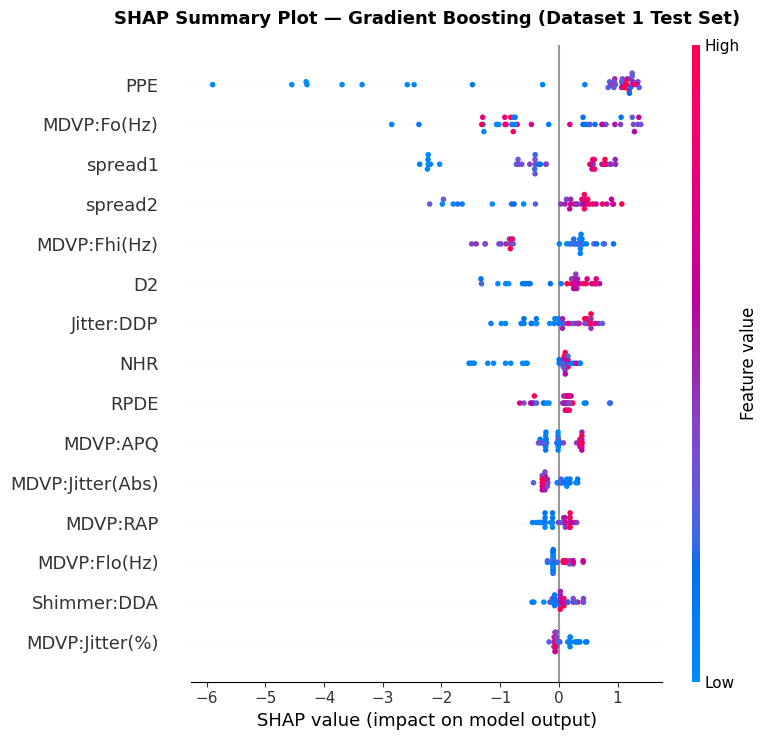

Saved: shap_summary_plot.png


In [6]:
plt.figure(figsize=(10, 7))
shap.summary_plot(
    shap_values_d1,
    X_test,
    plot_type='dot',
    show=False,
    max_display=15
)
plt.title('SHAP Summary Plot — Gradient Boosting (Dataset 1 Test Set)',
          fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('shap_summary_plot.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: shap_summary_plot.png")

### Interpretation of the Summary Plot:
-   Features at the top have the **highest impact** on predictions.
-   A red dot on the right indicates a high feature value pushes the prediction toward Parkinson's.
-   A blue dot on the right indicates a low feature value pushes the prediction toward Parkinson's.
-   A wide spread of dots signifies that the feature has a variable impact depending on the patient.

## 6. SHAP Bar Plot (Mean Absolute Feature Importance)

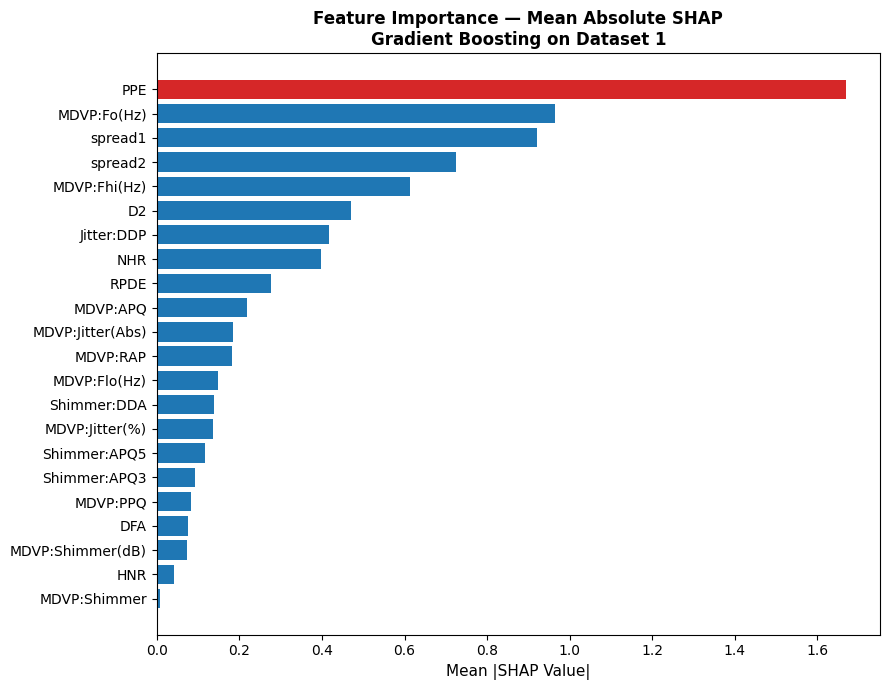

Top 5 most important features:
     Feature  Mean |SHAP|
         PPE     1.667980
 MDVP:Fo(Hz)     0.965325
     spread1     0.921666
     spread2     0.724062
MDVP:Fhi(Hz)     0.612546


In [7]:
# Mean absolute SHAP value per feature
mean_shap = pd.DataFrame({
    'Feature': X_test.columns,
    'Mean |SHAP|': np.abs(shap_values_d1).mean(axis=0)
}).sort_values('Mean |SHAP|', ascending=True)

plt.figure(figsize=(9, 7))
colors = ['#d62728' if v == mean_shap['Mean |SHAP|'].max() else '#1f77b4'
          for v in mean_shap['Mean |SHAP|']]
plt.barh(mean_shap['Feature'], mean_shap['Mean |SHAP|'], color=colors)
plt.xlabel('Mean |SHAP Value|', fontsize=11)
plt.title('Feature Importance — Mean Absolute SHAP\nGradient Boosting on Dataset 1',
          fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('shap_bar_plot.png', dpi=150, bbox_inches='tight')
plt.show()

# Print top 5
print("Top 5 most important features:")
print(mean_shap.sort_values('Mean |SHAP|', ascending=False).head(5).to_string(index=False))

## 7. SHAP Waterfall Plot (Individual Prediction Explanation)

This plot explains the prediction for the patient the model is **most confident** has Parkinson's, showing feature contributions step-by-step.

Selected patient index : 10
Actual label           : Parkinson's
Model confidence       : 0.9998 (toward Parkinson's)



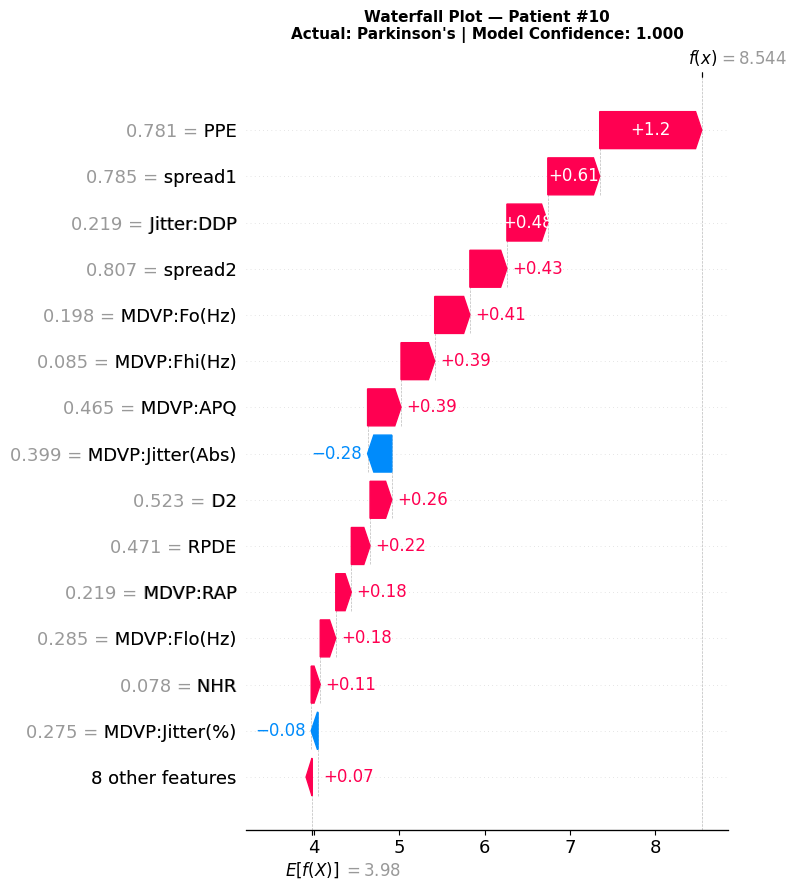

Saved: shap_waterfall_plot.png


In [8]:
# Use SHAP Explanation object for waterfall plot
explainer_obj = shap.TreeExplainer(gb_model)
shap_explanation = explainer_obj(X_test)

# Find the patient model is most confident has Parkinson's
proba = gb_model.predict_proba(X_test)[:, 1]
most_confident_idx = np.argmax(proba)

actual_label = y_test.iloc[most_confident_idx]
predicted_proba = proba[most_confident_idx]

print(f"Selected patient index : {most_confident_idx}")
print(f"Actual label           : {'Parkinson\'s' if actual_label == 1 else 'Healthy'}")
print(f"Model confidence       : {predicted_proba:.4f} (toward Parkinson's)")
print()

plt.figure(figsize=(10, 7))
shap.plots.waterfall(
    shap_explanation[most_confident_idx],
    max_display=15,
    show=False
)
plt.title(f"Waterfall Plot — Patient #{most_confident_idx}\n"
          f"Actual: {'Parkinson\'s' if actual_label==1 else 'Healthy'} | "
          f"Model Confidence: {predicted_proba:.3f}",
          fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('shap_waterfall_plot.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: shap_waterfall_plot.png")

### Interpretation of the Waterfall Plot:
-   **E[f(x)]** represents the model's average prediction (baseline) across all training samples.
-   **f(x)** is this specific patient's final prediction.
-   Each bar illustrates how much a feature pushed the prediction up (red) or down (blue).
-   Features are ordered by their impact for this individual patient.

## 8. SHAP Waterfall Plot (Healthy Patient Contrast)

This explains the prediction for the patient the model is most confident is **healthy**, highlighting features that pull predictions away from Parkinson's.

Selected patient index : 34
Actual label           : Healthy
Model confidence       : 0.0007 (toward Parkinson's)



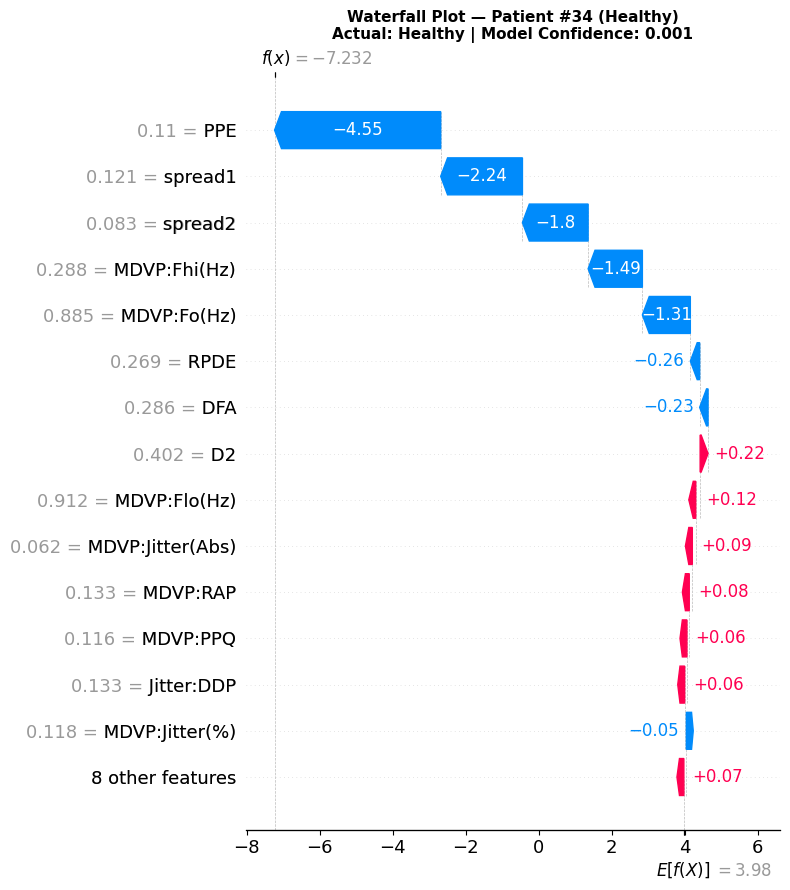

In [9]:
# Patient model is most confident is healthy
most_healthy_idx = np.argmin(proba)

actual_label_h = y_test.iloc[most_healthy_idx]
predicted_proba_h = proba[most_healthy_idx]

print(f"Selected patient index : {most_healthy_idx}")
print(f"Actual label           : {'Parkinson\'s' if actual_label_h == 1 else 'Healthy'}")
print(f"Model confidence       : {predicted_proba_h:.4f} (toward Parkinson's)")
print()

plt.figure(figsize=(10, 7))
shap.plots.waterfall(
    shap_explanation[most_healthy_idx],
    max_display=15,
    show=False
)
plt.title(f"Waterfall Plot — Patient #{most_healthy_idx} (Healthy)\n"
          f"Actual: {'Parkinson\'s' if actual_label_h==1 else 'Healthy'} | "
          f"Model Confidence: {predicted_proba_h:.3f}",
          fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('shap_waterfall_healthy.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Cross-Dataset SHAP Comparison (Dataset 1 vs Dataset 3)

This section investigates whether the model relies on the same features when applied to a completely different dataset. This is crucial for evaluating generalizability—a significant shift in feature importance might indicate overfitting to the training data distribution of Dataset 1.

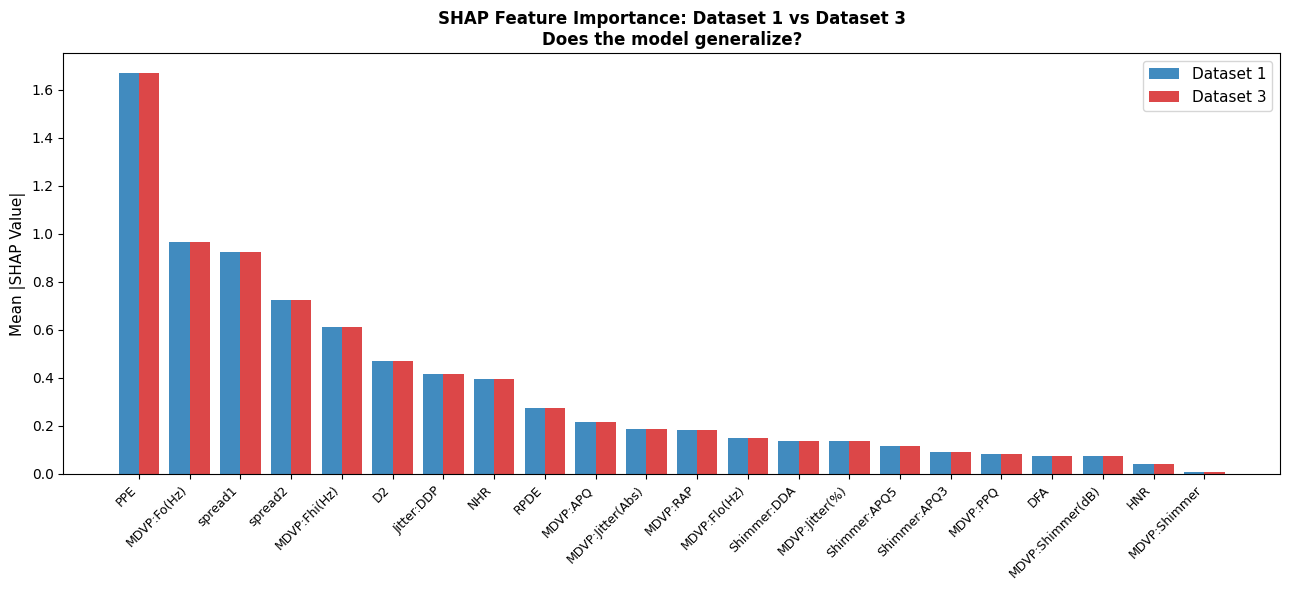

Features with largest importance shift (D1 → D3):
     Feature  SHAP D1  SHAP D3  Difference
         PPE 1.667980 1.667980         0.0
 MDVP:Fo(Hz) 0.965325 0.965325         0.0
     spread1 0.921666 0.921666         0.0
     spread2 0.724062 0.724062         0.0
MDVP:Fhi(Hz) 0.612546 0.612546         0.0


In [10]:
# Compute mean absolute SHAP for both datasets
mean_shap_d1 = np.abs(shap_values_d1).mean(axis=0)
mean_shap_d3 = np.abs(shap_values_d3).mean(axis=0)

# Combine into comparison dataframe
comparison_df = pd.DataFrame({
    'Feature'    : X_test.columns,
    'SHAP D1'    : mean_shap_d1,
    'SHAP D3'    : mean_shap_d3,
    'Difference' : np.abs(mean_shap_d1 - mean_shap_d3)
}).sort_values('SHAP D1', ascending=False)

# Plot side by side
x = np.arange(len(comparison_df))
width = 0.4

fig, ax = plt.subplots(figsize=(13, 6))
bars1 = ax.bar(x - width/2, comparison_df['SHAP D1'], width, label='Dataset 1', color='#1f77b4', alpha=0.85)
bars2 = ax.bar(x + width/2, comparison_df['SHAP D3'], width, label='Dataset 3', color='#d62728', alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(comparison_df['Feature'], rotation=45, ha='right', fontsize=9)
ax.set_ylabel('Mean |SHAP Value|', fontsize=11)
ax.set_title('SHAP Feature Importance: Dataset 1 vs Dataset 3\nDoes the model generalize?',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig('shap_cross_dataset_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# Show features with biggest shift in importance
print("Features with largest importance shift (D1 → D3):")
print(comparison_df[['Feature', 'SHAP D1', 'SHAP D3', 'Difference']]
      .sort_values('Difference', ascending=False)
      .head(5)
      .to_string(index=False))

### Interpretation of Cross-Dataset Comparison:
-   **Consistency** across D1 and D3 suggests the model generalizes well, relying on consistent voice signals.
-   **Significant shifts** in feature importance may indicate the model is picking up dataset-specific patterns rather than true Parkinson's biomarkers.
-   This analysis directly extends the generalization assessment beyond just accuracy metrics, complementing the findings in `SUPERVISED_PAPER_COMPARISON.ipynb`.

## 10. SHAP Dependence Plot (Top Feature Analysis)

This plot illustrates how the value of a specific feature relates to its SHAP contribution, with points colored by an automatically selected interaction feature.

Top feature by SHAP importance: PPE


<Figure size 900x500 with 0 Axes>

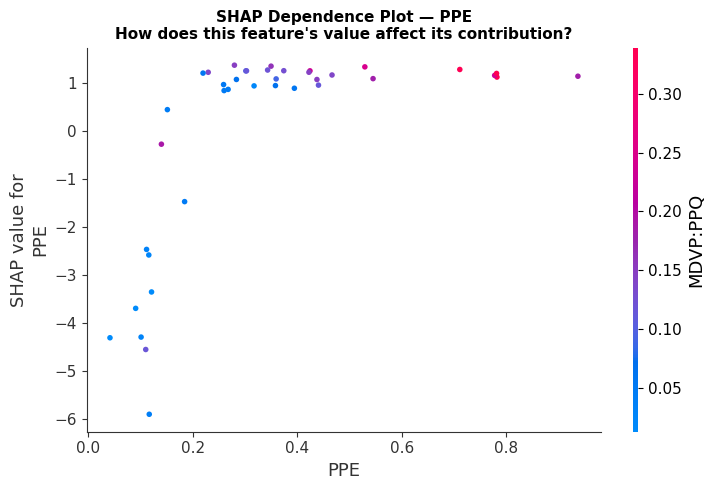

Saved: shap_dependence_plot.png


In [11]:
# Find top feature by mean absolute SHAP
top_feature = comparison_df.iloc[0]['Feature']
print(f"Top feature by SHAP importance: {top_feature}")

plt.figure(figsize=(9, 5))
shap.dependence_plot(
    top_feature,
    shap_values_d1,
    X_test,
    show=False
)
plt.title(f"SHAP Dependence Plot — {top_feature}\n"
          f"How does this feature's value affect its contribution?",
          fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('shap_dependence_plot.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: shap_dependence_plot.png")

## 11. Summary & Interpretation

In [12]:
print("=" * 60)
print("SHAP ANALYSIS SUMMARY")
print("=" * 60)

print("\nTop 5 features driving Parkinson's predictions:")
top5 = comparison_df.head(5)[['Feature', 'SHAP D1', 'SHAP D3']]
print(top5.to_string(index=False))

print("\nGeneralization check:")
top_d1 = set(comparison_df.head(5)['Feature'])
top_d3 = set(comparison_df.sort_values('SHAP D3', ascending=False).head(5)['Feature'])
overlap = top_d1.intersection(top_d3)
print(f"  Top-5 features overlapping between D1 and D3: {len(overlap)}/5")
print(f"  Overlapping features: {overlap}")

if len(overlap) >= 4:
    print("  → Model relies on consistent features across datasets (good generalization)")
elif len(overlap) >= 2:
    print("  → Partial overlap — some features consistent, some dataset-specific")
else:
    print("  → Low overlap — model may be fitting dataset-specific noise")

print("\nFiles saved:")
for f in ['shap_summary_plot.png', 'shap_bar_plot.png',
          'shap_waterfall_plot.png', 'shap_waterfall_healthy.png',
          'shap_cross_dataset_comparison.png', 'shap_dependence_plot.png']:
    print(f"  {f}")

SHAP ANALYSIS SUMMARY

Top 5 features driving Parkinson's predictions:
     Feature  SHAP D1  SHAP D3
         PPE 1.667980 1.667980
 MDVP:Fo(Hz) 0.965325 0.965325
     spread1 0.921666 0.921666
     spread2 0.724062 0.724062
MDVP:Fhi(Hz) 0.612546 0.612546

Generalization check:
  Top-5 features overlapping between D1 and D3: 5/5
  Overlapping features: {'MDVP:Fo(Hz)', 'PPE', 'spread2', 'MDVP:Fhi(Hz)', 'spread1'}
  → Model relies on consistent features across datasets (good generalization)

Files saved:
  shap_summary_plot.png
  shap_bar_plot.png
  shap_waterfall_plot.png
  shap_waterfall_healthy.png
  shap_cross_dataset_comparison.png
  shap_dependence_plot.png


---

## Key Takeaways

- **SHAP makes the model auditable** — a doctor or reviewer can see exactly which voice measurements triggered a Parkinson's prediction and by how much
- **Cross-dataset SHAP comparison** extends the generalization analysis beyond just accuracy metrics — it shows whether the model is using the same reasoning on unseen data
- **Individual explanations** (waterfall plots) demonstrate the model treats each patient differently, not applying a single rule to everyone

---